# Interprétation — Cardio Train (modèle clinique)

Objectif : comprendre *ce que le modèle a appris*, confronter ses facteurs prédictifs aux
connaissances médicales, et identifier ses limites.

On repart des artefacts sauvegardés par `python -m src.train_model`
(`models/cardio_train/metrics.json`).

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

with open("../../models/cardio_train/metrics.json") as f:
    summary = json.load(f)

print("Meilleur modèle :", summary["best_model"])
best = summary["models"][summary["best_model"]]
print(f"ROC-AUC : {best['roc_auc']:.3f} | Accuracy : {best['accuracy']:.3f} | "
      f"Recall : {best['recall']:.3f} | Précision : {best['precision']:.3f}")

Meilleur modèle : Random Forest
ROC-AUC : 0.807 | Accuracy : 0.739 | Recall : 0.683 | Précision : 0.765


## 1. Quels facteurs pèsent le plus ?

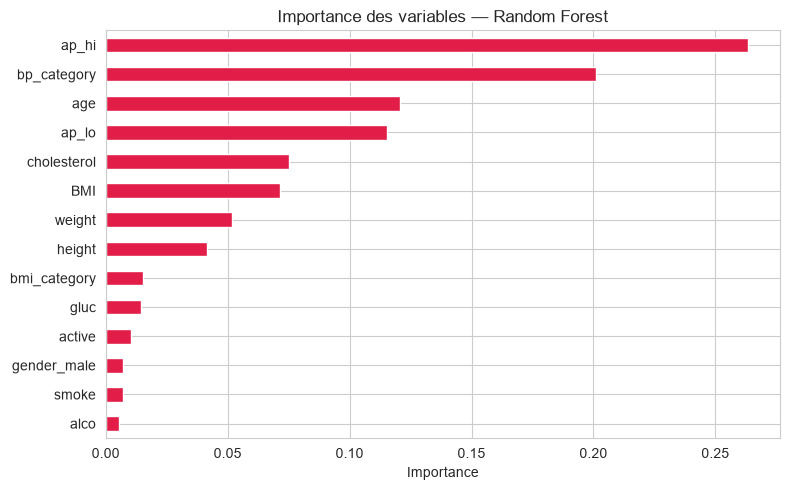

ap_hi           0.263
bp_category     0.201
age             0.121
ap_lo           0.116
cholesterol     0.075
BMI             0.071
weight          0.052
height          0.041
bmi_category    0.015
gluc            0.015
active          0.010
gender_male     0.007
smoke           0.007
alco            0.005
dtype: float64

In [2]:
importance = pd.Series(summary["feature_importance"]).abs().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importance.sort_values().plot.barh(color="#e11d48")
plt.title(f"Importance des variables — {summary['best_model']}")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importance.round(3)

## 2. Lecture clinique

- **La pression artérielle domine** : `ap_hi` (systolique) + la variable dérivée `bp_category`
  concentrent à elles seules près de la moitié de l'importance totale. C'est cohérent avec la
  littérature médicale — l'hypertension est le premier facteur de risque cardiovasculaire modifiable.
- **L'âge** vient ensuite : le risque augmente fortement après 50 ans (confirmé par l'EDA, où la
  prévalence passe de ~24% chez les 30-39 ans à ~74% chez les 60-69 ans).
- **Cholestérol et IMC** complètent le tableau, en cohérence avec les facteurs de risque connus.
- **Tabac, alcool, activité physique pèsent étonnamment peu** dans ce modèle. Deux explications
  probables : (1) ces variables sont auto-déclarées et binaires, donc peu informatives ;
  (2) leur effet transite en partie par les variables cliniques (le tabac et la sédentarité
  élèvent la tension, qui elle est mesurée directement).

## 3. Ce que la variable dérivée apporte

`bp_category` (catégorisation AHA de la tension) arrive 2ᵉ en importance : la catégorisation
clinique apporte au modèle des seuils explicites que la valeur brute seule n'encode pas — un bon
exemple de feature engineering guidé par la connaissance métier.

## 4. Limites de l'interprétation

- **Corrélation ≠ causalité** : l'importance mesure l'utilité prédictive, pas l'effet causal.
- La feature importance de Random Forest est **biaisée en faveur des variables continues** à
  nombreuses valeurs (âge, tension) au détriment des binaires (tabac, alcool).
- Le dataset provient d'une population russe hospitalière : la hiérarchie des facteurs pourrait
  différer sur une autre population.
- Ces résultats **ne remplacent pas un avis médical** — le modèle est un outil pédagogique.